# Model Analysis

This notebook develops and compares logistic regression models to predict customer response to a monthly food basket subscription campaign for a retail food company. Building on the exploratory data analysis conducted previously, which identified behavioral variables, particularly past campaign acceptance and recency, as the strongest predictors of response, the modelling approach follows a structured diagnostic logic: regularized full-feature model is estimated first to identify which predictors survive penalization, motivating two targeted deep-dives into behavioral and demographic drivers respectively.

## 0. Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

In [7]:
# Data loading
df = pd.read_csv('../data/marketing_campaign_clean.csv')

# Data overview
print(f"Dataset shape: {df.shape}")
print(f"\nClass balance:")
print(df['Response'].value_counts(normalize=True).round(3))
df.columns

Dataset shape: (2236, 30)

Class balance:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


Index(['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Income_missing', 'Customer_Tenure', 'Age',
       'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
       'Response'],
      dtype='object')

## 1. Feature Selection

In [5]:
# Clean Marital_Status
df['Marital_Status'] = df['Marital_Status'].replace({'Absurd': 'Single', 'YOLO': 'Single', 'Alone': 'Single'})

df_model = df.copy()

#Drop columns that won't be used in the model
cols_to_drop = [
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Income_missing', 'Complain'
]

df_model = df_model.drop(columns=cols_to_drop)


# Define features and target

## Full Model
numerical_features_full = [
    'Age', 'Income', 'Recency', 'Customer_Tenure',
    'Total_Spending', 'Total_Purchases', 'Total_Accepted_Campaigns',
    'NumDealsPurchases', 'NumWebVisitsMonth',
    'Kidhome', 'Teenhome'
]
categorical_features_full = ['Education', 'Marital_Status']

## Behavioural Model
numerical_features_behav = [
    'Recency', 'Total_Spending', 'Total_Purchases',
    'Total_Accepted_Campaigns', 'NumDealsPurchases', 'NumWebVisitsMonth'
]
categorical_features_behav = [] 

# Demographic Model
numerical_features_demo = [
    'Age', 'Income', 'Customer_Tenure',
    'Kidhome', 'Teenhome'
]
categorical_features_demo = ['Education', 'Marital_Status']

target = 'Response'

## 2. Sample Split

In [ ]:
# Define X and y
X = df_model[numerical_features_full + categorical_features_full]
y = df_model[target]

#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1788, 13)
Test shape: (448, 13)


## 3. Full Model with Regularization 

### 3.1. Preprocessing Pipeline & Full Logistic Regression

In [10]:
## Preprocessing Pipeline (Full Model)
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features_full)
    ]
)

## Full Logistic Regression (L1)

full_model_l1 = Pipeline(steps=[
    ('preprocessor', preprocessor_full),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        random_state=42
    ))
])

full_model_l1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Income', 'Recency',
                                                   'Customer_Tenure',
                                                   'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth',
                                                   'Kidhome', 'Teenhome']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Education',
                                                   'Marital_Status'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

### 3.2. Model Evaluation

In [ ]:
## Predictions
y_pred_full = full_model_l1.predict(X_test)
y_prob_full = full_model_l1.predict_proba(X_test)[:,1]

## Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_full = accuracy_score(y_test, y_pred_full)
precision_full = precision_score(y_test, y_pred_full)
recall_full = recall_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)
auc_full = roc_auc_score(y_test, y_prob_full)

print("Accuracy:", accuracy_full)
print("Precision:", precision_full)
print("Recall:", recall_full)
print("F1:", f1_full)
print("ROC-AUC:", auc_full)

Accuracy: 0.8839285714285714
Precision: 0.6923076923076923
Recall: 0.40298507462686567
F1: 0.5094339622641509
ROC-AUC: 0.8795393113174285


### 3.3. Confusion Matrix

We developed a confusion matrix to show how the model’s predictions compare to the actual campaign responses. 

This is important because, for example, predicting that a customer will respond when they do not 
may lead to unnecessary campaign costs, while predicting that a customer will not respond when 
they actually would means missing a potential opportunity.

The confusion matrix therefore helps evaluate whether the model is better at identifying 
responders or non-responders.

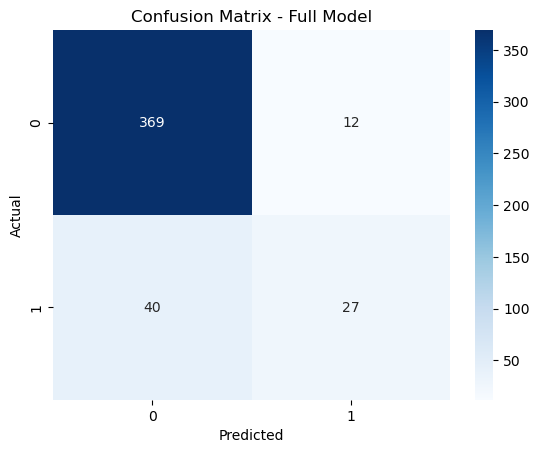

In [17]:
cm = confusion_matrix(y_test, y_pred_full)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Full Model")
plt.show()

### 3.4. ROC Curve

We used the ROC curve for later to compare with the different models, as it measures the 
overall ability of the model to rank customers by their likelihood of responding.

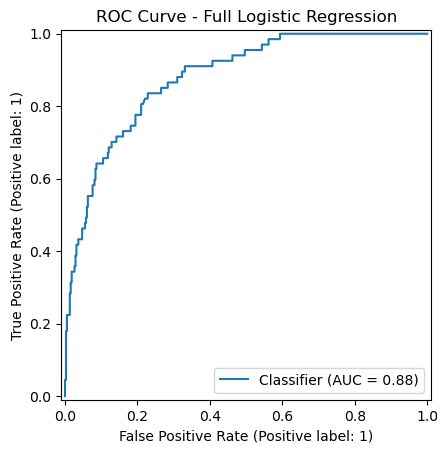

In [14]:
RocCurveDisplay.from_predictions(y_test, y_prob_full)
plt.title("ROC Curve - Full Logistic Regression")
plt.show()

### 3.5. Feature Importance
To understand which variables influence campaign response, we analyze the coefficients 
of the logistic regression model.

In [15]:
ohe = full_model_l1.named_steps['preprocessor'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(categorical_features_full)

all_features = numerical_features_full + list(cat_features)

coefficients = full_model_l1.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
6,Total_Accepted_Campaigns,1.077775
3,Customer_Tenure,0.900227
14,Education_PhD,0.728310
7,NumDealsPurchases,0.246272
4,Total_Spending,0.241997
1,Income,0.204701
8,NumWebVisitsMonth,0.177356
0,Age,0.121646
9,Kidhome,0.089726
13,Education_Master,0.081417


### 3.6. Plot Important Drivers

To make the interpretation easier, we use vizualizations to learn the most influential positive and negative 
predictors of campaign response.

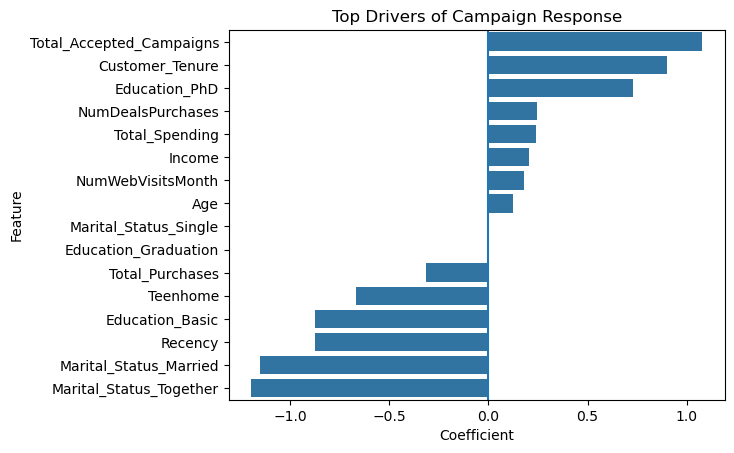

In [16]:
top_pos = coef_df.head(8)
top_neg = coef_df.tail(8)

coef_plot = pd.concat([top_pos, top_neg])

sns.barplot(data=coef_plot, x="Coefficient", y="Feature")
plt.axvline(0)
plt.title("Top Drivers of Campaign Response")
plt.show()

### 3.7. Interpretation of Full Model Results

The full logistic regression model provides a general view of which factors influence campaign response. The model achieves strong predictive performance (ROC-AUC = 0.88), correctly identifying most non-responders (369) but missing a number of actual responders (40), which is reflected in the relatively lower recall.

The most important positive drivers of response include previous campaign acceptance, customer tenure, total spending, and income, suggesting that more engaged and higher-value customers are more likely to respond to marketing campaigns.

However, this model combines both demographic characteristics and behavioural variables.

To better understand the drivers of response, we estimate two additional models:

• A **demographic model** focusing on customer characteristics  
• A **behavioural model** focusing on engagement and purchasing behaviour  

Comparing these models allows us to evaluate whether campaign response is better explained by **who the customer is** or by **how the customer behaves**.

## 4. Behavioural Model

To better understand the role of customer engagement and purchasing behaviour in campaign response, we estimate a logistic regression model using only behavioural variables.
### 4.1 Data for Behavioural Model

In [18]:
X_behav = df_model[numerical_features_behav + categorical_features_behav]
y_behav = df_model[target]

X_train_behav, X_test_behav, y_train_behav, y_test_behav = train_test_split(
    X_behav,
    y_behav,
    test_size=0.2,
    stratify=y_behav,
    random_state=42
)

### 4.2. Preprocessing & Behavioural Logistic Regression

In [21]:
preprocessor_behav = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_behav)
    ]
)

behav_model = Pipeline(steps=[
    ('preprocessor', preprocessor_behav),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

behav_model.fit(X_train_behav, y_train_behav)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Recency', 'Total_Spending',
                                                   'Total_Purchases',
                                                   'Total_Accepted_Campaigns',
                                                   'NumDealsPurchases',
                                                   'NumWebVisitsMonth'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### 4.3. Predictions and Metrics

In [22]:
y_pred_behav = behav_model.predict(X_test_behav)
y_prob_behav = behav_model.predict_proba(X_test_behav)[:,1]

print(classification_report(y_test_behav, y_pred_behav))
print("ROC-AUC:", roc_auc_score(y_test_behav, y_prob_behav))

              precision    recall  f1-score   support

           0       0.88      0.97      0.93       381
           1       0.64      0.27      0.38        67

    accuracy                           0.87       448
   macro avg       0.76      0.62      0.65       448
weighted avg       0.85      0.87      0.84       448

ROC-AUC: 0.8519606690954675


### 4.4 Confusion Matrix

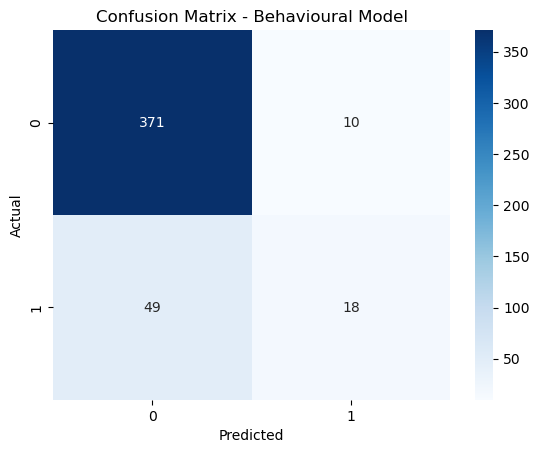

In [23]:
cm_behav = confusion_matrix(y_test_behav, y_pred_behav)

sns.heatmap(cm_behav, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Behavioural Model")
plt.show()

### 4.5 ROC Curve

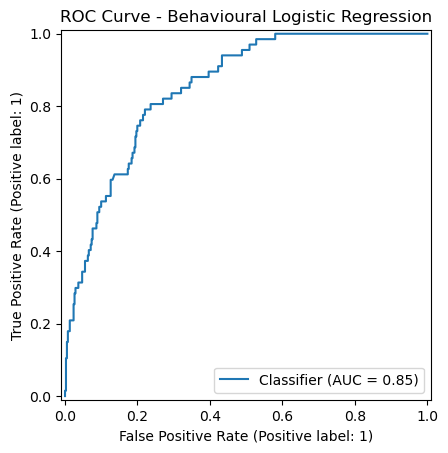

In [24]:
RocCurveDisplay.from_predictions(y_test_behav, y_prob_behav)
plt.title("ROC Curve - Behavioural Logistic Regression")
plt.show()

### 4.7. Feature Importance

In [25]:
coefficients_behav = behav_model.named_steps['classifier'].coef_[0]

coef_df_behav = pd.DataFrame({
    "Feature": numerical_features_behav,
    "Coefficient": coefficients_behav
}).sort_values(by="Coefficient", ascending=False)

coef_df_behav

,Feature,Coefficient
3,Total_Accepted_Campaigns,0.832794
1,Total_Spending,0.688011
5,NumWebVisitsMonth,0.431559
4,NumDealsPurchases,0.066452
2,Total_Purchases,-0.255469
0,Recency,-0.756381


### 4.7. Important Drivers Plot

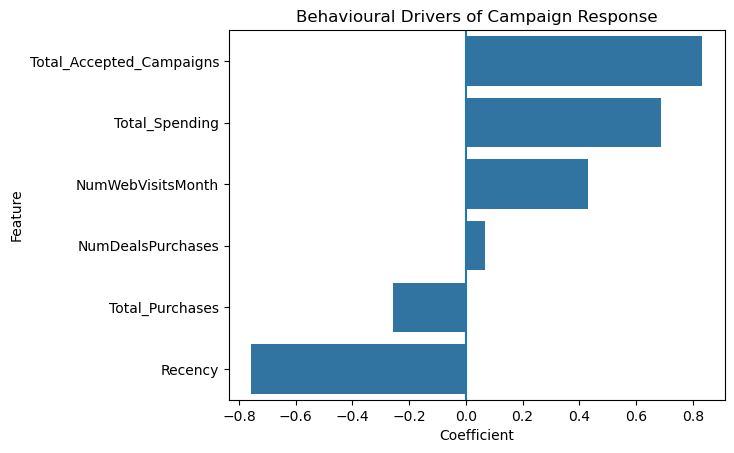

In [26]:
top_pos = coef_df_behav.head(5)
top_neg = coef_df_behav.tail(5)

coef_plot = pd.concat([top_pos, top_neg])

sns.barplot(data=coef_plot, x="Coefficient", y="Feature")
plt.axvline(0)
plt.title("Behavioural Drivers of Campaign Response")
plt.show()

## 4. Demographic & Household Model

## 5. Summary of Results

## 6. Business Recommendations